# Сравнение ранее сохранённых траекторий

Этот сценарий не запускает имитацию. Он читает CSV базового опыта, проверяет
их структуру и строит двухпанельное сравнение только позиций `Eat_i`.

In [1]:
using DrWatson
@quickactivate "PetriDiningLab"

ENV["GKSwstype"] = "100"
using CairoMakie
using CSV
using DataFrames
using Statistics

include(srcdir("DiningPhilosophers.jl"))
using .DiningPhilosophers

## Чтение результатов базового опыта

In [2]:
const PHILOSOPHERS = 5
classic_path = datadir("dining_classic.csv")
arbiter_path = datadir("dining_arbiter.csv")
for path in (classic_path, arbiter_path)
    isfile(path) || error("Сначала выполните dining_philosophers.jl: " * path)
end

classic = CSV.read(classic_path, DataFrame)
arbiter = CSV.read(arbiter_path, DataFrame)
eat_columns = philosopher_columns("Eat", PHILOSOPHERS)

for frame in (classic, arbiter)
    all(column -> column in propertynames(frame), eat_columns) ||
        error("В сохранённой траектории отсутствуют позиции Eat_i")
    issorted(frame.time) || error("Временные отметки CSV не упорядочены")
end

## Двухпанельная диаграмма

In [3]:
colors = [:royalblue3, :darkorange2, :seagreen3, :firebrick2, :mediumpurple3]
figure = Figure(size=(1150, 820), fontsize=16)
for (row, (name, frame)) in enumerate((("Классическая сеть", classic),
                                        ("Сеть с арбитром", arbiter)))
    axis = Axis(figure[row, 1], title=name, xlabel="Время",
                ylabel="Eat (0/1)", yticks=0:1)
    for philosopher in 1:PHILOSOPHERS
        stairs!(axis, frame.time, frame[!, eat_columns[philosopher]];
                step=:post, linewidth=2, color=colors[philosopher],
                label="Философ $(philosopher)")
    end
    axislegend(axis; position=:rt, nbanks=PHILOSOPHERS, labelsize=11)
end
save(plotsdir("final_report.png"), figure, px_per_unit=1.5)

## Численные показатели из CSV

2×6 DataFrame
 Row │ variant            rows   final_time  max_simultaneous  active_share  zero_tail
     │ String             Int64  Float64     Int64             Float64       Bool
─────┼─────────────────────────────────────────────────────────────────────────────────
   1 │ Классическая сеть      6    0.446562                 0      0.0            true
   2 │ Сеть с арбитром       78   50.0                      1      0.333333      false


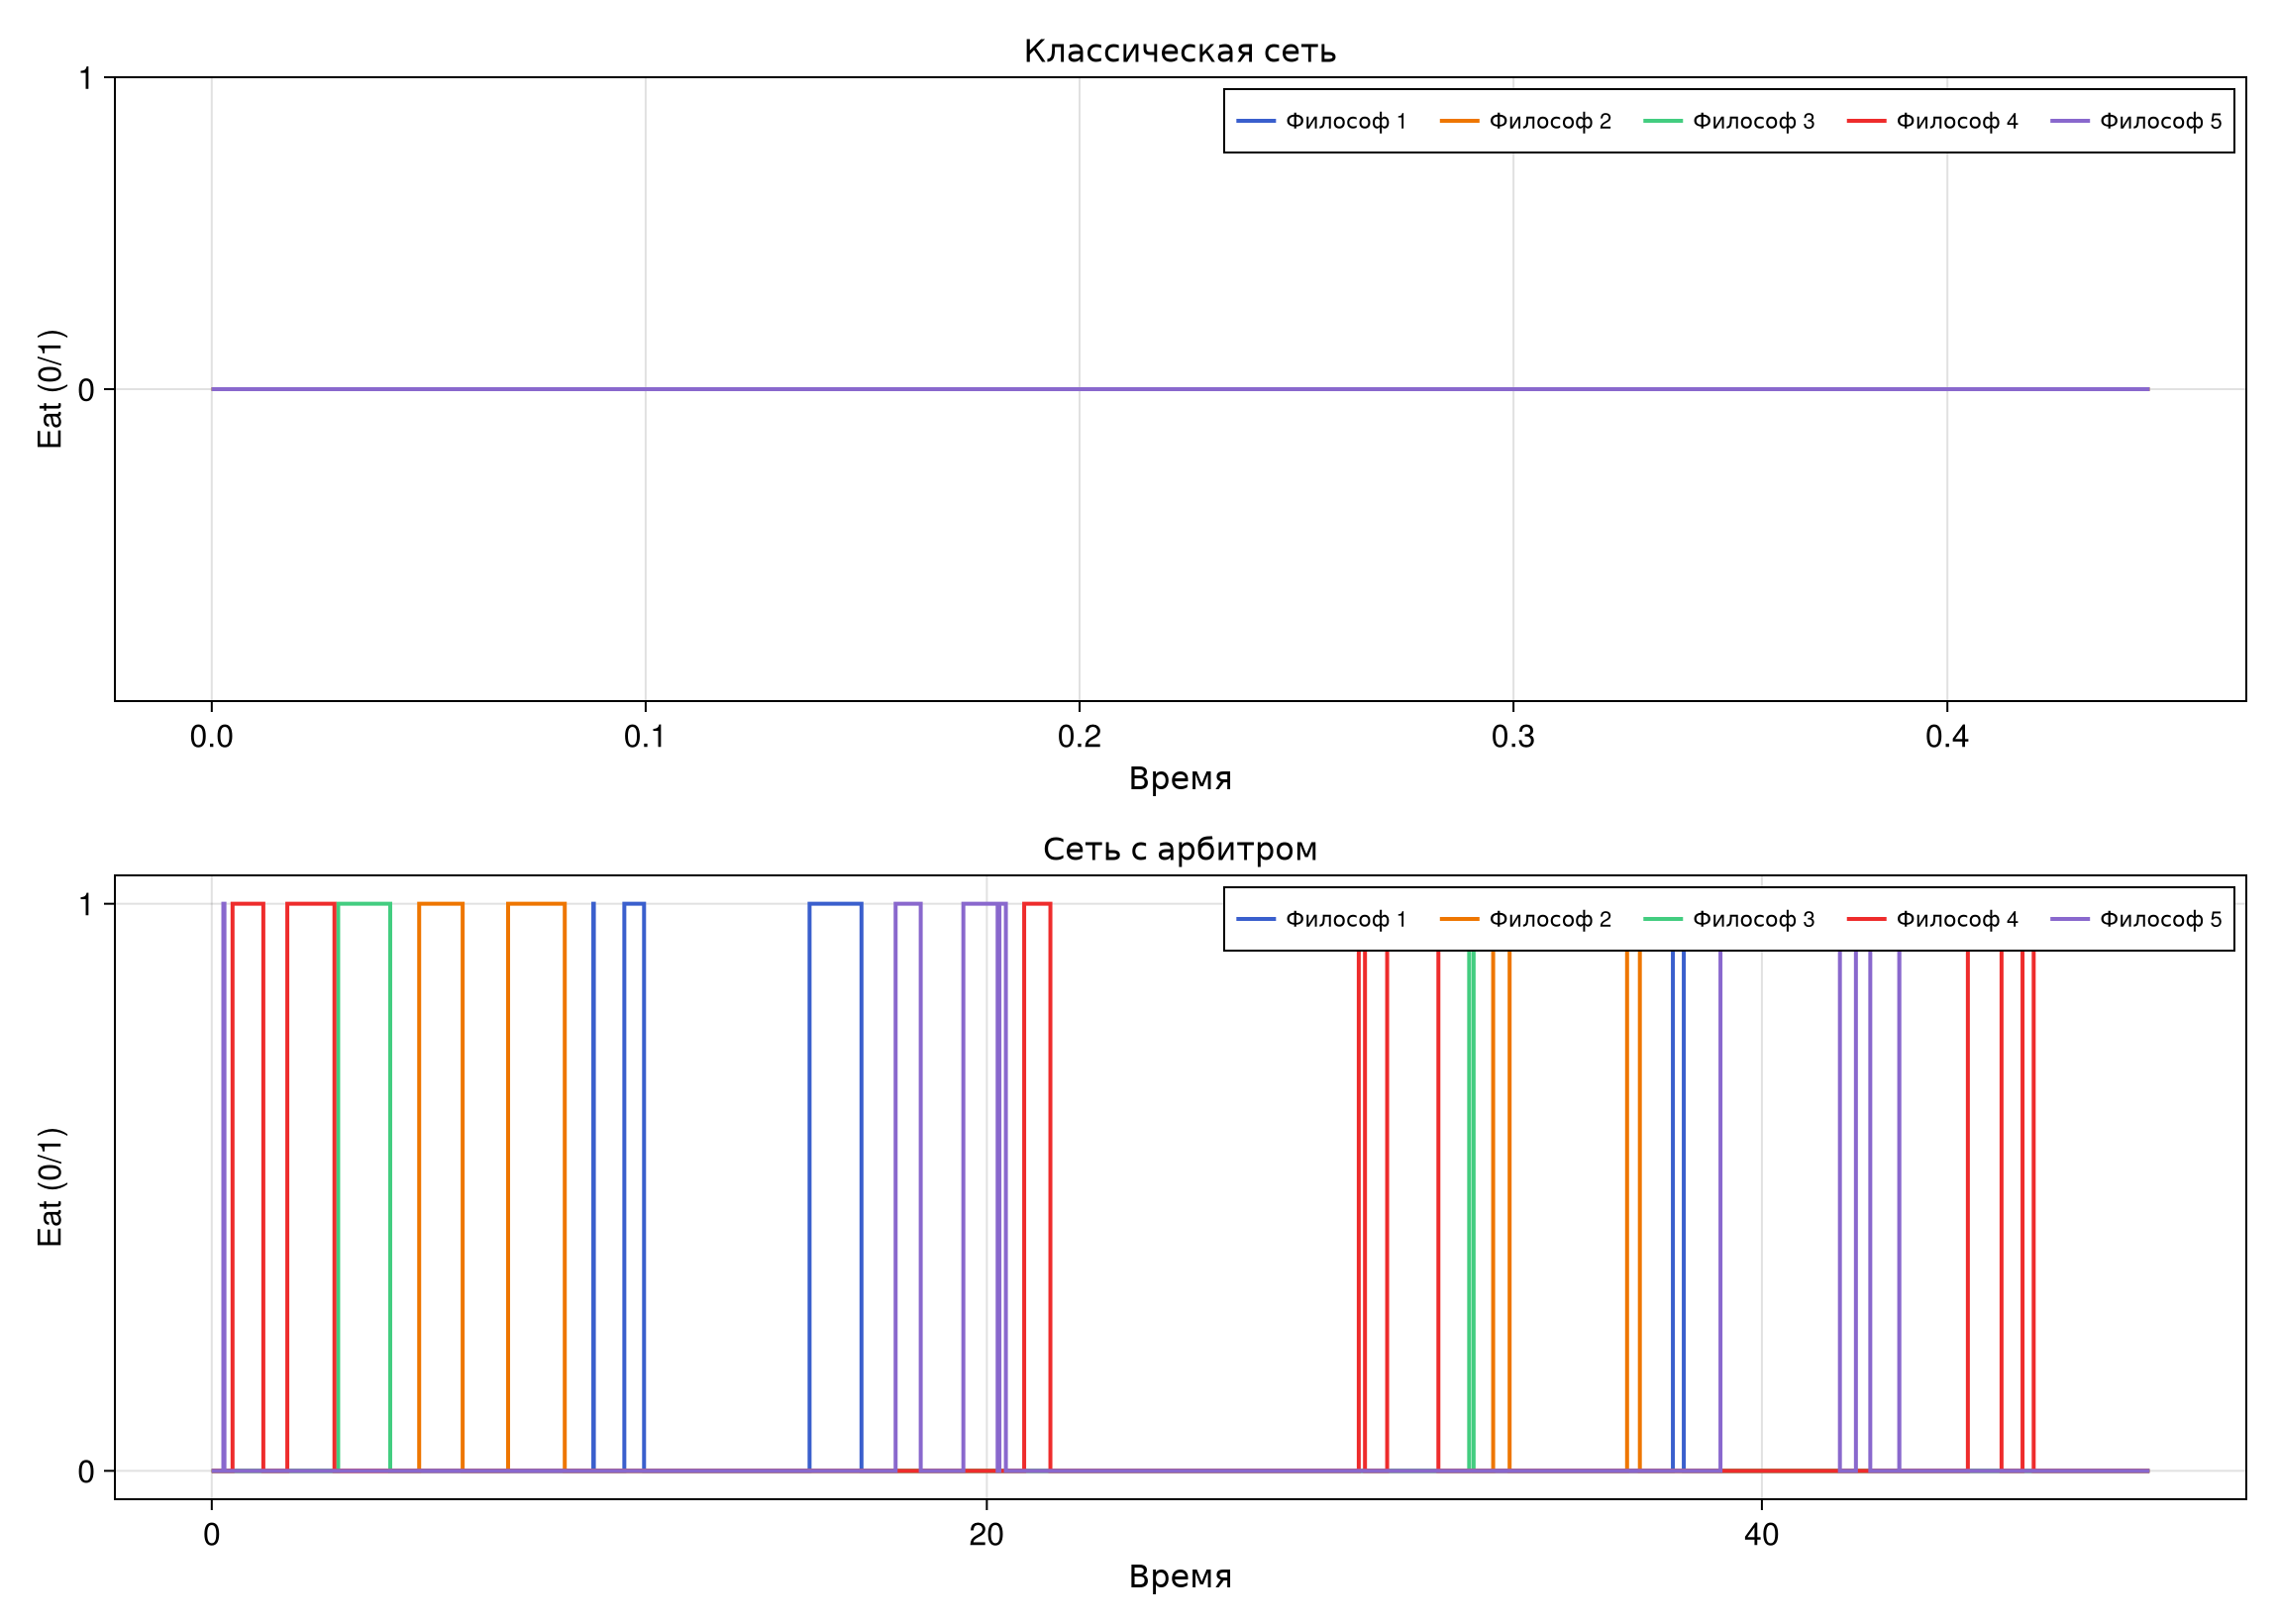

In [4]:
function activity_metrics(name, frame)
    eat_matrix = Matrix(frame[:, eat_columns])
    active_rows = vec(sum(eat_matrix; dims=2))
    (variant=name, rows=nrow(frame), final_time=last(frame.time),
     max_simultaneous=maximum(active_rows),
     active_share=mean(active_rows .> 0),
     zero_tail=all(iszero, active_rows[max(1, end - 3):end]))
end

comparison = DataFrame([
    activity_metrics("Классическая сеть", classic),
    activity_metrics("Сеть с арбитром", arbiter),
])
CSV.write(datadir("dining_report_summary.csv"), comparison)
show(comparison; allrows=true, allcols=true)
println()
figure

У классической сети завершающий нулевой участок связан с отсутствием
разрешённых переходов. Для сети с арбитром CSV заканчивается на горизонте,
поэтому нулевая строка сама по себе не интерпретируется как deadlock.